# A qualitative investigation of locality and anti-locality effects within lossy-context surprisal
This thesis aims to investigate whether or not lossy-context surprisal (Futrell et al., 2021), at least qualitatively, has the requisite mechanisms necessary to explain both locality and anti-locality effects and interactions between them within a coherent framework.

In [49]:
import toylossy
import seaborn as sns
import grammars
from nltk.grammar import PCFG
import expdata
import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings("ignore")

del_rate = 0.2

## The syntactic complexity of Russian relative clauses

In [50]:
pcfg_russian = PCFG.fromstring(grammars.gen_russian_grammar_exp2(0.6, 0.8, 0.4, 0.7, 0.2, 0.95))
model_russian = toylossy.LCModel(pcfg_russian, del_rate)

### Experiment 1
In this experiment, local and non-local RC configurations were tested to ascertain the reading time at the verb, first and foremost. The results were the following:

<AxesSubplot:xlabel='Locality', ylabel='Mean reading time (ms)'>

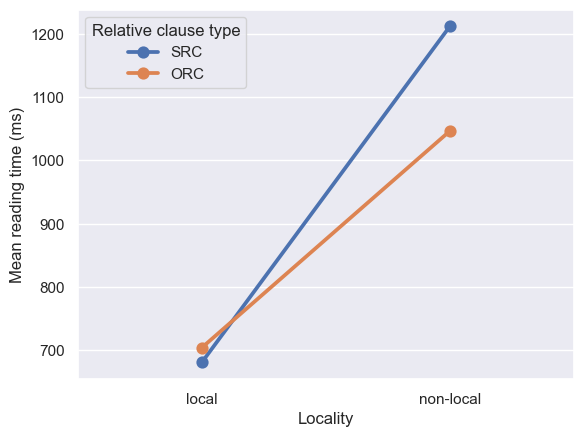

In [51]:
sns.set_theme()

sns.pointplot(expdata.levy_exp1a_verb,
              x = "Locality", 
              y = "Mean reading time (ms)", 
              hue = "Relative clause type"
)

We run the model with the parameters assigned as above and get the following plot:

<AxesSubplot:xlabel='Locality', ylabel='Predicted processing difficulty'>

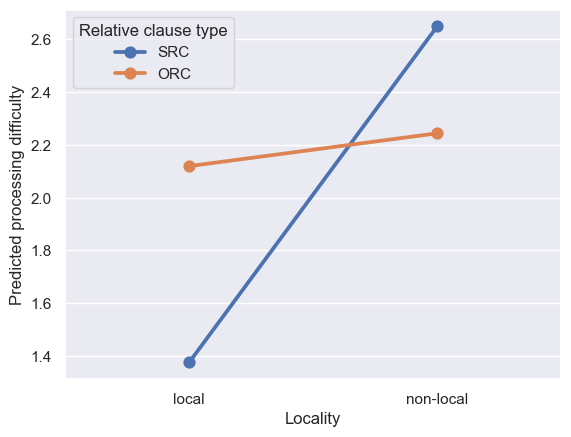

In [52]:
src_local = model_russian.calculate_processing_difficulty("RPNom V".split())
src_non_local = model_russian.calculate_processing_difficulty("RPNom DO V".split())

orc_local = model_russian.calculate_processing_difficulty("RPAcc V".split())
orc_non_local = model_russian.calculate_processing_difficulty("RPAcc Subj V".split())

sim_data_exp1 = pd.DataFrame({
    "Predicted processing difficulty": [src_local, src_non_local, orc_local, orc_non_local],
    "Relative clause type": ["SRC", "SRC", "ORC", "ORC"],
    "Locality": ["local", "non-local", "local", "non-local"]
})

sns.lineplot(sim_data_exp1, 
             x = "Locality", 
             y = "Predicted processing difficulty", 
             hue = "Relative clause type",
             legend = None
)

sns.pointplot(sim_data_exp1,
              x = "Locality", 
              y = "Predicted processing difficulty", 
              hue = "Relative clause type"
)

As we can see, although the differences between SRCs and ORCs are much greater in the model, the qualatitive pattern is there:

 - The verb is read slower in the non-local conditions, and
 - local ORCs are read slower than local SRCs, but non-local ORCs are faster than non-local SRCs.

Levy et al. (2013) also looked at the reading time on accusative NPs (in the grammar called 'DO'), and found that these were read slower when placed preverbally than postverbally.

In [53]:
preverbal_acc = model_russian.calculate_processing_difficulty("RPNom DO".split())
postverbal_acc = model_russian.calculate_processing_difficulty("RPNom V DO".split())

diff = preverbal_acc - postverbal_acc
print(diff)







0.6138041221709338


As we can see from this output, the model predicts that preverbal accusative NPs have a higher processing difficulty than postverbal accusative NPs. This is to be expected from an expectation-based standpoint, since, as Levy et al. discuss, local SRC configurations are much more common, meaning a comprehender should expect the word following the nominative relative pronoun to be a verb, not a direct object.

## Experiment 2
The goal of the second experiment was to more directly manipulate the distance between the relative pronoun and the verb. They did this by adding one or two interveners that were either verb arguments (direct object + indirect object) or adjuncts. They results were the following.

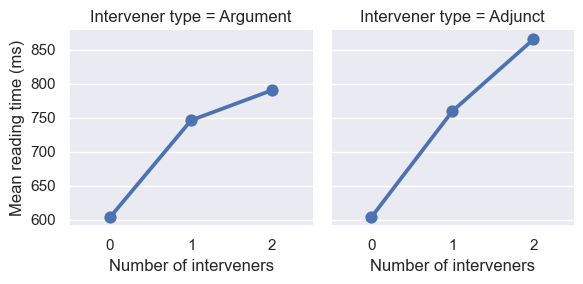

In [54]:
grid = sns.FacetGrid(expdata.levy_exp2a_verb, col = "Intervener type")

grid.map(sns.pointplot, "Number of interveners", "Mean reading time (ms)")

For both types of intervener, the reading time rises monotonically at the verb. We can now see what the model predicts for this.

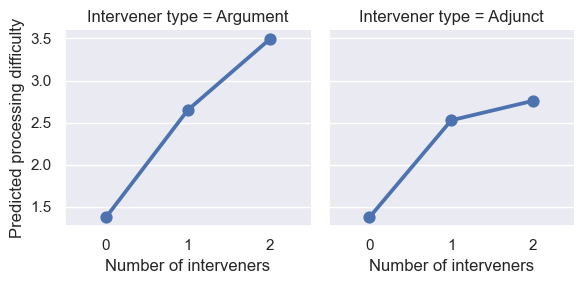

In [55]:
no_intv = model_russian.calculate_processing_difficulty("RPNom V".split())
one_arg = model_russian.calculate_processing_difficulty("RPNom DO V".split())
two_arg = model_russian.calculate_processing_difficulty("RPNom DO IO V".split())

one_adj = model_russian.calculate_processing_difficulty("RPNom Adj V".split())
two_adj = model_russian.calculate_processing_difficulty("RPNom Adj Adj V".split())

sim_data_exp2 = pd.DataFrame({
    "Predicted processing difficulty": [no_intv, one_arg, two_arg, no_intv, one_adj, two_adj],
    "Number of interveners": [0, 1, 2, 0, 1, 2],
    "Intervener type": ["Argument", "Argument", "Argument", "Adjunct", "Adjunct", "Adjunct"]
})

grid = sns.FacetGrid(sim_data_exp2, col = "Intervener type")
grid.map(sns.pointplot, "Number of interveners", "Predicted processing difficulty")